# Astronomical Object Clustering Pipeline
## Unsupervised classification of Stars, Galaxies, and Quasars

**Dataset:** 10,000 spectroscopically confirmed observations  
**Task:** Cluster objects by photometric properties — *without* using class labels  
**Evaluation:** Post-hoc comparison of clusters to ground-truth labels (STAR, GALAXY, QSO)

## Data Loading and Cleaning

In [110]:
import pandas as pd
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from sklearn.preprocessing import QuantileTransformer

In [111]:
DATA_PATH = "star-galaxy-quasar.csv"
df_raw = pd.read_csv(DATA_PATH, skiprows=1)
print(f"Raw shape: {df_raw.shape}")
print("Columns:", list(df_raw.columns))

Raw shape: (10000, 10)
Columns: ['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


In [112]:
df_raw.head(3)

,objid,ra,dec,u,g,r,i,z,class,redshift
0,1237654669735231608,149.142428,-0.372420,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,149.117936,0.183976,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,149.156198,-0.315231,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327


### Drop `ra` and `dec`

Right ascension and declination are sky coordinates — they tell us *where* an object is, not *what* it is. In a general photometric survey, all three object types are distributed across the sky with no systematic spatial segregation. These columns add noise to distance calculations.

In [113]:
df_clean = df_raw.drop(columns=['ra', 'dec'])
print(f"Shape after dropping coords: {df_clean.shape}")

Shape after dropping coords: (10000, 8)


### Remove outliers

Outliers are identified following these rules:  
1. For each band in u, g, r, i, z:
- value must be strictly between -50 and 50
- so values <= -50 or >= 50 are removed
2. redshift must be >= 0

In [114]:
# Filter for valid photometric values
bands = ['u', 'g', 'r', 'i', 'z']
for band in bands:
    df_clean = df_clean[(df_clean[band] > -50) & (df_clean[band] < 50)]

# Filter for valid redshift
df_clean = df_clean[df_clean['redshift'] >= 0]

print(f"Shape after removing outliers: {df_clean.shape}")

# Check for any NaN values
print("NaN counts:")
print(df_clean.isnull().sum())

Shape after removing outliers: (9744, 8)
NaN counts:
objid       0
u           0
g           0
r           0
i           0
z           0
class       0
redshift    0
dtype: int64


In [115]:
# Prepare features and labels
X_raw = df_clean[['u', 'g', 'r', 'i', 'z', 'redshift']]
y = df_clean['class']

print(f"X_raw shape: {X_raw.shape}")
print(f"y shape: {y.shape}")
print(f"X_raw columns: {list(X_raw.columns)}")
print(f"y classes:\n{y.value_counts().to_string()}")

X_raw shape: (9744, 6)
y shape: (9744,)
X_raw columns: ['u', 'g', 'r', 'i', 'z', 'redshift']
y classes:
class
GALAXY    8434
QSO        685
STAR       625


In [116]:
X_raw.head(3)

,u,g,r,i,z,redshift
0,19.76743,17.87560,16.90248,16.45606,16.12213,0.091934
1,18.20582,16.46298,15.49704,14.95910,14.60985,0.065808
2,19.78793,18.33921,17.48833,17.07277,16.74467,0.085327


In [117]:
df_clean.head(3)

,objid,u,g,r,i,z,class,redshift
0,1237654669735231608,19.76743,17.87560,16.90248,16.45606,16.12213,GALAXY,0.091934
1,1237651801233686770,18.20582,16.46298,15.49704,14.95910,14.60985,GALAXY,0.065808
2,1237651800696881217,19.78793,18.33921,17.48833,17.07277,16.74467,GALAXY,0.085327


## Preliminary EDA

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

In [119]:
print("Basic statistics for features:")
X_raw.describe()

Basic statistics for features:


,u,g,r,i,z,redshift
count,9744.000000,9744.000000,9744.000000,9744.000000,9744.000000,9744.000000
mean,19.907014,18.273652,17.399159,16.991397,16.709745,0.193853
std,1.536770,1.218813,1.063988,1.065531,1.088634,0.334260
min,11.960910,12.374760,12.297430,12.184350,11.806450,0.000000
25%,19.034585,17.612568,16.834655,16.429282,16.120378,0.071194
50%,19.680960,18.192615,17.389270,16.976215,16.677580,0.103591
75%,20.438260,18.718367,17.789500,17.386222,17.152540,0.162942
max,28.238530,25.532540,24.801930,30.831510,26.259070,6.827977


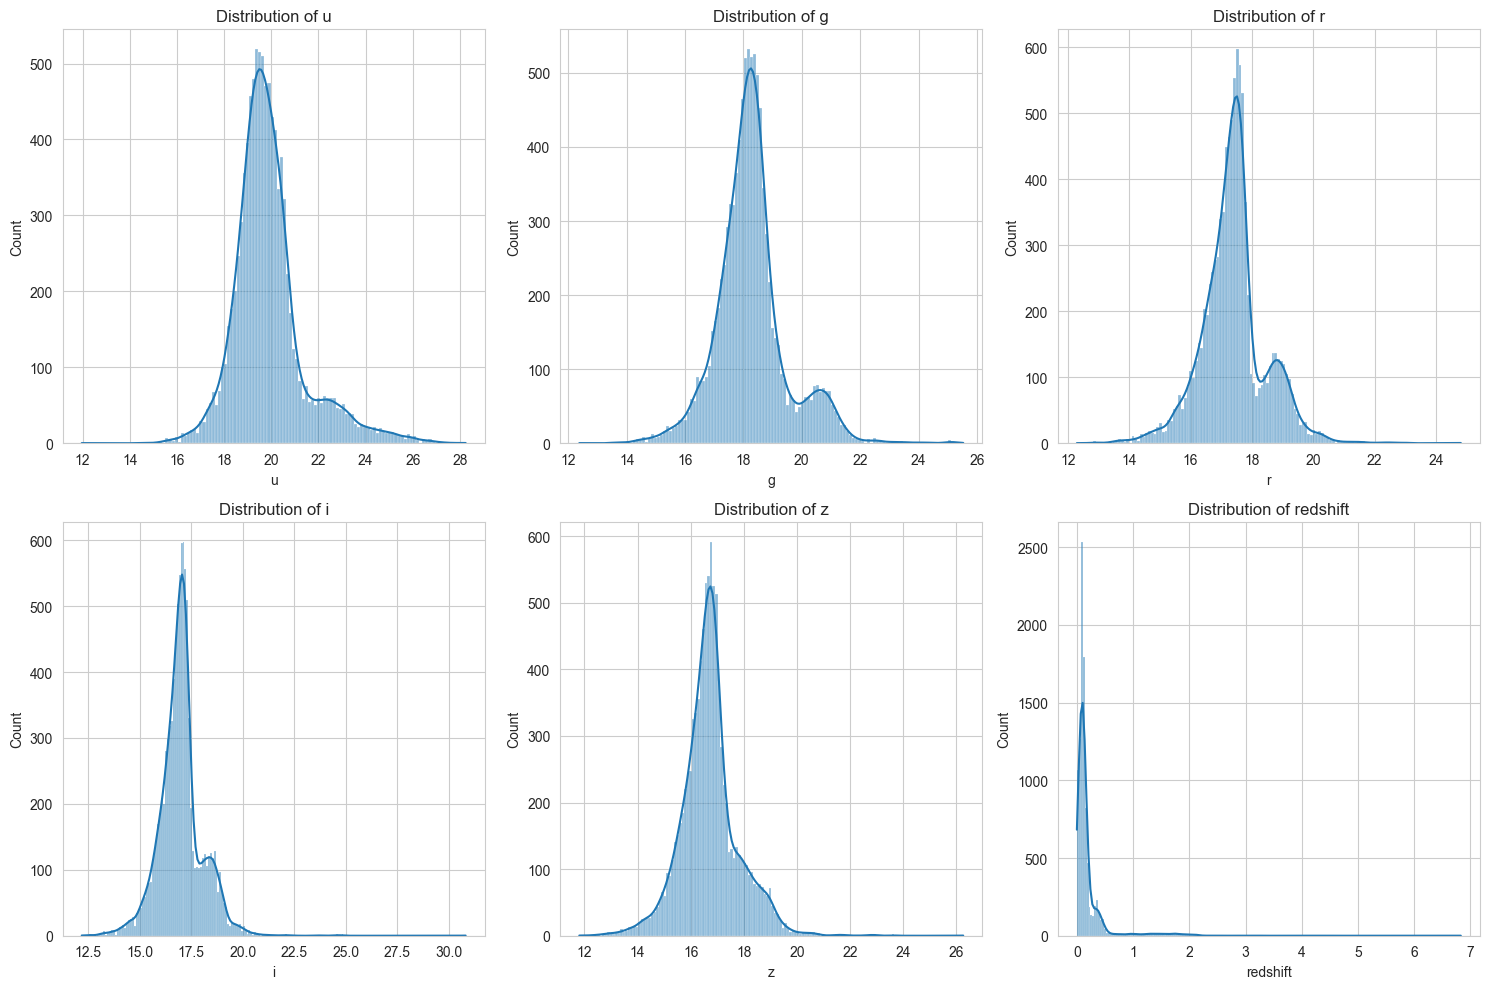

In [120]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(X_raw.columns):
    sns.histplot(X_raw[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

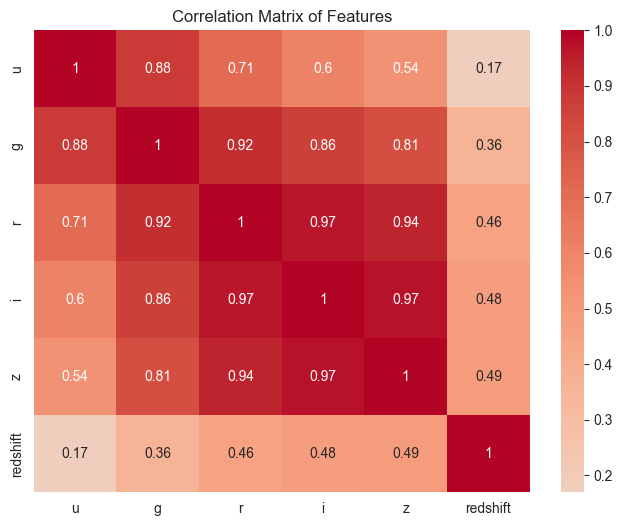

In [121]:
# Correlation matrix
corr = X_raw.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Features')
plt.show()

## Feature Engineering

In [122]:
# Create feature dataframe
X_features = X_raw.copy()
print(f"Starting with {X_features.shape[1]} base features")

Starting with 6 base features


### Layer 1: Color Features

### Basic Colors
- **u_g**: Encodes temperature (UV sensitivity); distinguishes hot stars/quasars from cool objects.
- **g_r**: Primary optical classifier; separates stellar locus from galaxy locus; tracks galaxy age.
- **r_i**: Infrared sensitivity; less dust-affected than g-r; breaks color degeneracies.
- **i_z**: Far-infrared color; least dust-affected; detects cool objects and dust diagnostics.
- **u_r**: Broadest wavelength range; maximum temperature discrimination leverage.
- **g_i**: Optical to near-IR; balanced SED characterization across spectrum.
- **g_z**: Extreme wavelength span; dust and age diagnostics.

In [123]:
# BASIC COLORS
X_features['u_g'] = X_features['u'] - X_features['g']
X_features['g_r'] = X_features['g'] - X_features['r']
X_features['r_i'] = X_features['r'] - X_features['i']
X_features['i_z'] = X_features['i'] - X_features['z']
X_features['u_r'] = X_features['u'] - X_features['r']
X_features['g_i'] = X_features['g'] - X_features['i']
X_features['g_z'] = X_features['g'] - X_features['z']

### SED Slope
- **sed_slope_full**: Distinguishes thermal objects (positive slope) from non-thermal quasars (negative); detects dust reddening.
- **sed_slope_optical**: UV-to-optical slope; isolates hot component of SED; quasars have steep negative slopes.
- **sed_slope_ir**: Infrared slope; less dust-affected; complements optical slope to avoid dust confusion.

In [124]:
# SED SLOPE
wavelengths = np.array([3550, 4770, 6231, 7625, 9134])
def compute_sed_slope(row):
    mags = np.array([row['u'], row['g'], row['r'], row['i'], row['z']])
    if np.isnan(mags).any():
        return np.nan
    slope, _ = np.polyfit(wavelengths, mags, 1)
    return slope
X_features['sed_slope_full'] = X_features[['u', 'g', 'r', 'i', 'z']].apply(compute_sed_slope, axis=1)
X_features['sed_slope_optical'] = (X_features['g'] - X_features['u']) / (4770 - 3550)
X_features['sed_slope_ir'] = (X_features['z'] - X_features['i']) / (9134 - 7625)

### Color Statistics
- **color_mean**: Average color indicates overall "redness"; separates population types without computing all colors.
- **color_std**: Measures color diversity; breaks red/dust degeneracies; distinguishes homogeneous from mixed populations.
- **color_range**: SED diversity metric; robust outlier-resistant version of color_std.

In [125]:
# COLOR STATISTICS
colors_array = np.array([X_features['u_g'], X_features['g_r'], X_features['r_i'], X_features['i_z']]).T
X_features['color_mean'] = colors_array.mean(axis=1)
X_features['color_std'] = colors_array.std(axis=1)
X_features['color_range'] = colors_array.max(axis=1) - colors_array.min(axis=1)

## Layer 2: Magnitude Features

### Apparent Magnitude Statistics
- **mag_mean**: Average brightness proxy; independent brightness indicator without distance.
- **mag_std**: Spectral diversity metric; high std = blue+red (mixed), low std = uniform SED.
- **mag_range**: Captures magnitude spread; robust measure of SED structure.
- **mag_median**: Robust average brightness measure; less sensitive to outliers than mag_mean.
- **mag_cv**: Coefficient of variation; normalized brightness diversity; scale-invariant SED descriptor.

In [126]:
mag_cols = ['u', 'g', 'r', 'i', 'z']

# APPARENT MAGNITUDE STATISTICS
X_features['mag_mean'] = X_features[mag_cols].mean(axis=1)
X_features['mag_std'] = X_features[mag_cols].std(axis=1)
X_features['mag_range'] = X_features[mag_cols].max(axis=1) - X_features[mag_cols].min(axis=1)
X_features['mag_median'] = X_features[mag_cols].median(axis=1)
X_features['mag_cv'] = X_features['mag_std'] / (X_features['mag_mean'] + 1e-10)

## Layer 3: Redshift & Distance Features

### Cosmic Time
- **lookback_time_Gyr**: Time since emission; places objects in cosmic history; tracks universe evolution.
- **cosmic_age_at_z_Gyr**: Age of universe at redshift z; contextualizes object formation epoch.
- **scale_factor_a**: Expansion factor; needed for physical size/age transformations; direct cosmological parameter.

In [127]:
# COSMIC TIME
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
X_features['lookback_time_Gyr'] = 13.8 - cosmo.age(X_features['redshift']).value
X_features['cosmic_age_at_z_Gyr'] = cosmo.age(X_features['redshift']).value
X_features['scale_factor_a'] = 1.0 / (1 + X_features['redshift'])

## Layer 4: Classification & Composite Features

### Galaxy Type
- **galaxy_type**: Tracks galaxy evolution; separates passive (old) from star-forming (young) populations.

In [128]:
# GALAXY TYPE (Color-based)
X_features['likely_galaxy_type'] = pd.cut(
    X_features['g_r'],
    bins=[-np.inf, 0.5, 0.7, np.inf],
    labels=['blue_cloud', 'green_valley', 'red_sequence']
)

### Stellar Type
- **stellar_type**: Estimates stellar temperature without spectroscopy; enables stellar population studies.

In [129]:
# STELLAR TYPE (Color-based)
X_features['likely_stellar_type'] = pd.cut(
    X_features['g_r'],
    bins=[-np.inf, 0.3, 0.6, 1.0, np.inf],
    labels=['OB_type', 'AF_type', 'G_type', 'KM_type']
)

### Quasar Likelihood Score
- **quasar_score**: Identifies quasars via non-thermal colors; enables pre-spectroscopy candidate selection.

In [130]:
# QUASAR LIKELIHOOD SCORE
def compute_quasar_score(row):
    score = 0.0
    if row['u_g'] < -0.3: score += 0.3
    if row['g_r'] < 0: score += 0.3
    if (row['u_g'] < -0.5) and (row['g_r'] < -0.2): score += 0.2
    return min(1.0, score)
X_features['quasar_score'] = X_features.apply(compute_quasar_score, axis=1)

### Brightness Population
- **brightness_pop**: Captures sample structure (two populations at g~19 and g~23); accounts for selection bias.
- **brightness_percentile**: Normalized brightness ranking; enables quantile-based stratification.

In [131]:
# BRIGHTNESS POPULATION
X_features['brightness_pop'] = np.where(X_features['g'] < 21, 'bright', 'faint')
X_features['brightness_percentile'] = X_features['g'].rank(pct=True) * 100

### Data Quality
- **mag_smoothness**: Detects SED anomalies; flags spurious or contaminated photometry.
- **magnitude_anomaly**: Binary flag for problematic measurements; enables quality-based sample filtering.

In [132]:
# DATA QUALITY
def mag_smoothness(row):
    mags = np.array([row['u'], row['g'], row['r'], row['i'], row['z']])
    if np.isnan(mags).any():
        return np.nan
    return np.std(np.diff(mags))
X_features['mag_smoothness'] = X_features.apply(mag_smoothness, axis=1)
X_features['magnitude_anomaly'] = (X_features['mag_smoothness'] > 0.3).astype(int)

## Feature Engineering EDA

In [133]:
print("Engineered features shape:", X_features.shape)
print("Sample of engineered features:")
X_features.iloc[:3, 6:]  # Show first 3 rows, columns after base features

Engineered features shape: (9744, 34)
Sample of engineered features:


,u_g,g_r,r_i,i_z,u_r,g_i,g_z,sed_slope_full,sed_slope_optical,sed_slope_ir,...,lookback_time_Gyr,cosmic_age_at_z_Gyr,scale_factor_a,likely_galaxy_type,likely_stellar_type,quasar_score,brightness_pop,brightness_percentile,mag_smoothness,magnitude_anomaly
0,1.89183,0.97312,0.44642,0.33393,2.86495,1.41954,1.75347,-0.000613,-0.001551,-0.000221,...,1.536065,12.263935,0.915806,red_sequence,G_type,0.0,bright,34.359606,0.615372,1
1,1.74284,0.96594,0.53794,0.34925,2.70878,1.50388,1.85313,-0.000613,-0.001429,-0.000231,...,1.210055,12.589945,0.938256,red_sequence,G_type,0.0,bright,5.100575,0.535989,1
2,1.44872,0.85088,0.41556,0.32810,2.29960,1.26644,1.59454,-0.000518,-0.001187,-0.000217,...,1.454756,12.345244,0.921381,red_sequence,G_type,0.0,bright,57.558498,0.443782,1


In [134]:
# Basic statistics for ALL engineered features
print("Summary statistics for all 42 features:")
X_features.describe().T  # Transpose for better readability

Summary statistics for all 42 features:


,count,mean,std,min,25%,50%,75%,max
u,9744.0,19.907014,1.536770,11.960910,19.034585,19.680960,20.438260,28.238530
g,9744.0,18.273652,1.218813,12.374760,17.612568,18.192615,18.718367,25.532540
r,9744.0,17.399159,1.063988,12.297430,16.834655,17.389270,17.789500,24.801930
i,9744.0,16.991397,1.065531,12.184350,16.429282,16.976215,17.386222,30.831510
z,9744.0,16.709745,1.088634,11.806450,16.120378,16.677580,17.152540,26.259070
redshift,9744.0,0.193853,0.334260,0.000000,0.071194,0.103591,0.162942,6.827977
u_g,9744.0,1.633362,0.738189,-8.235660,1.226665,1.681500,1.971430,8.175870
g_r,9744.0,0.874493,0.475746,-6.683520,0.595660,0.881840,1.053355,8.396770
r_i,9744.0,0.407761,0.272133,-12.963090,0.351247,0.424610,0.477973,7.161740
i_z,9744.0,0.281652,0.252033,-5.649330,0.214387,0.317025,0.364583,11.546050


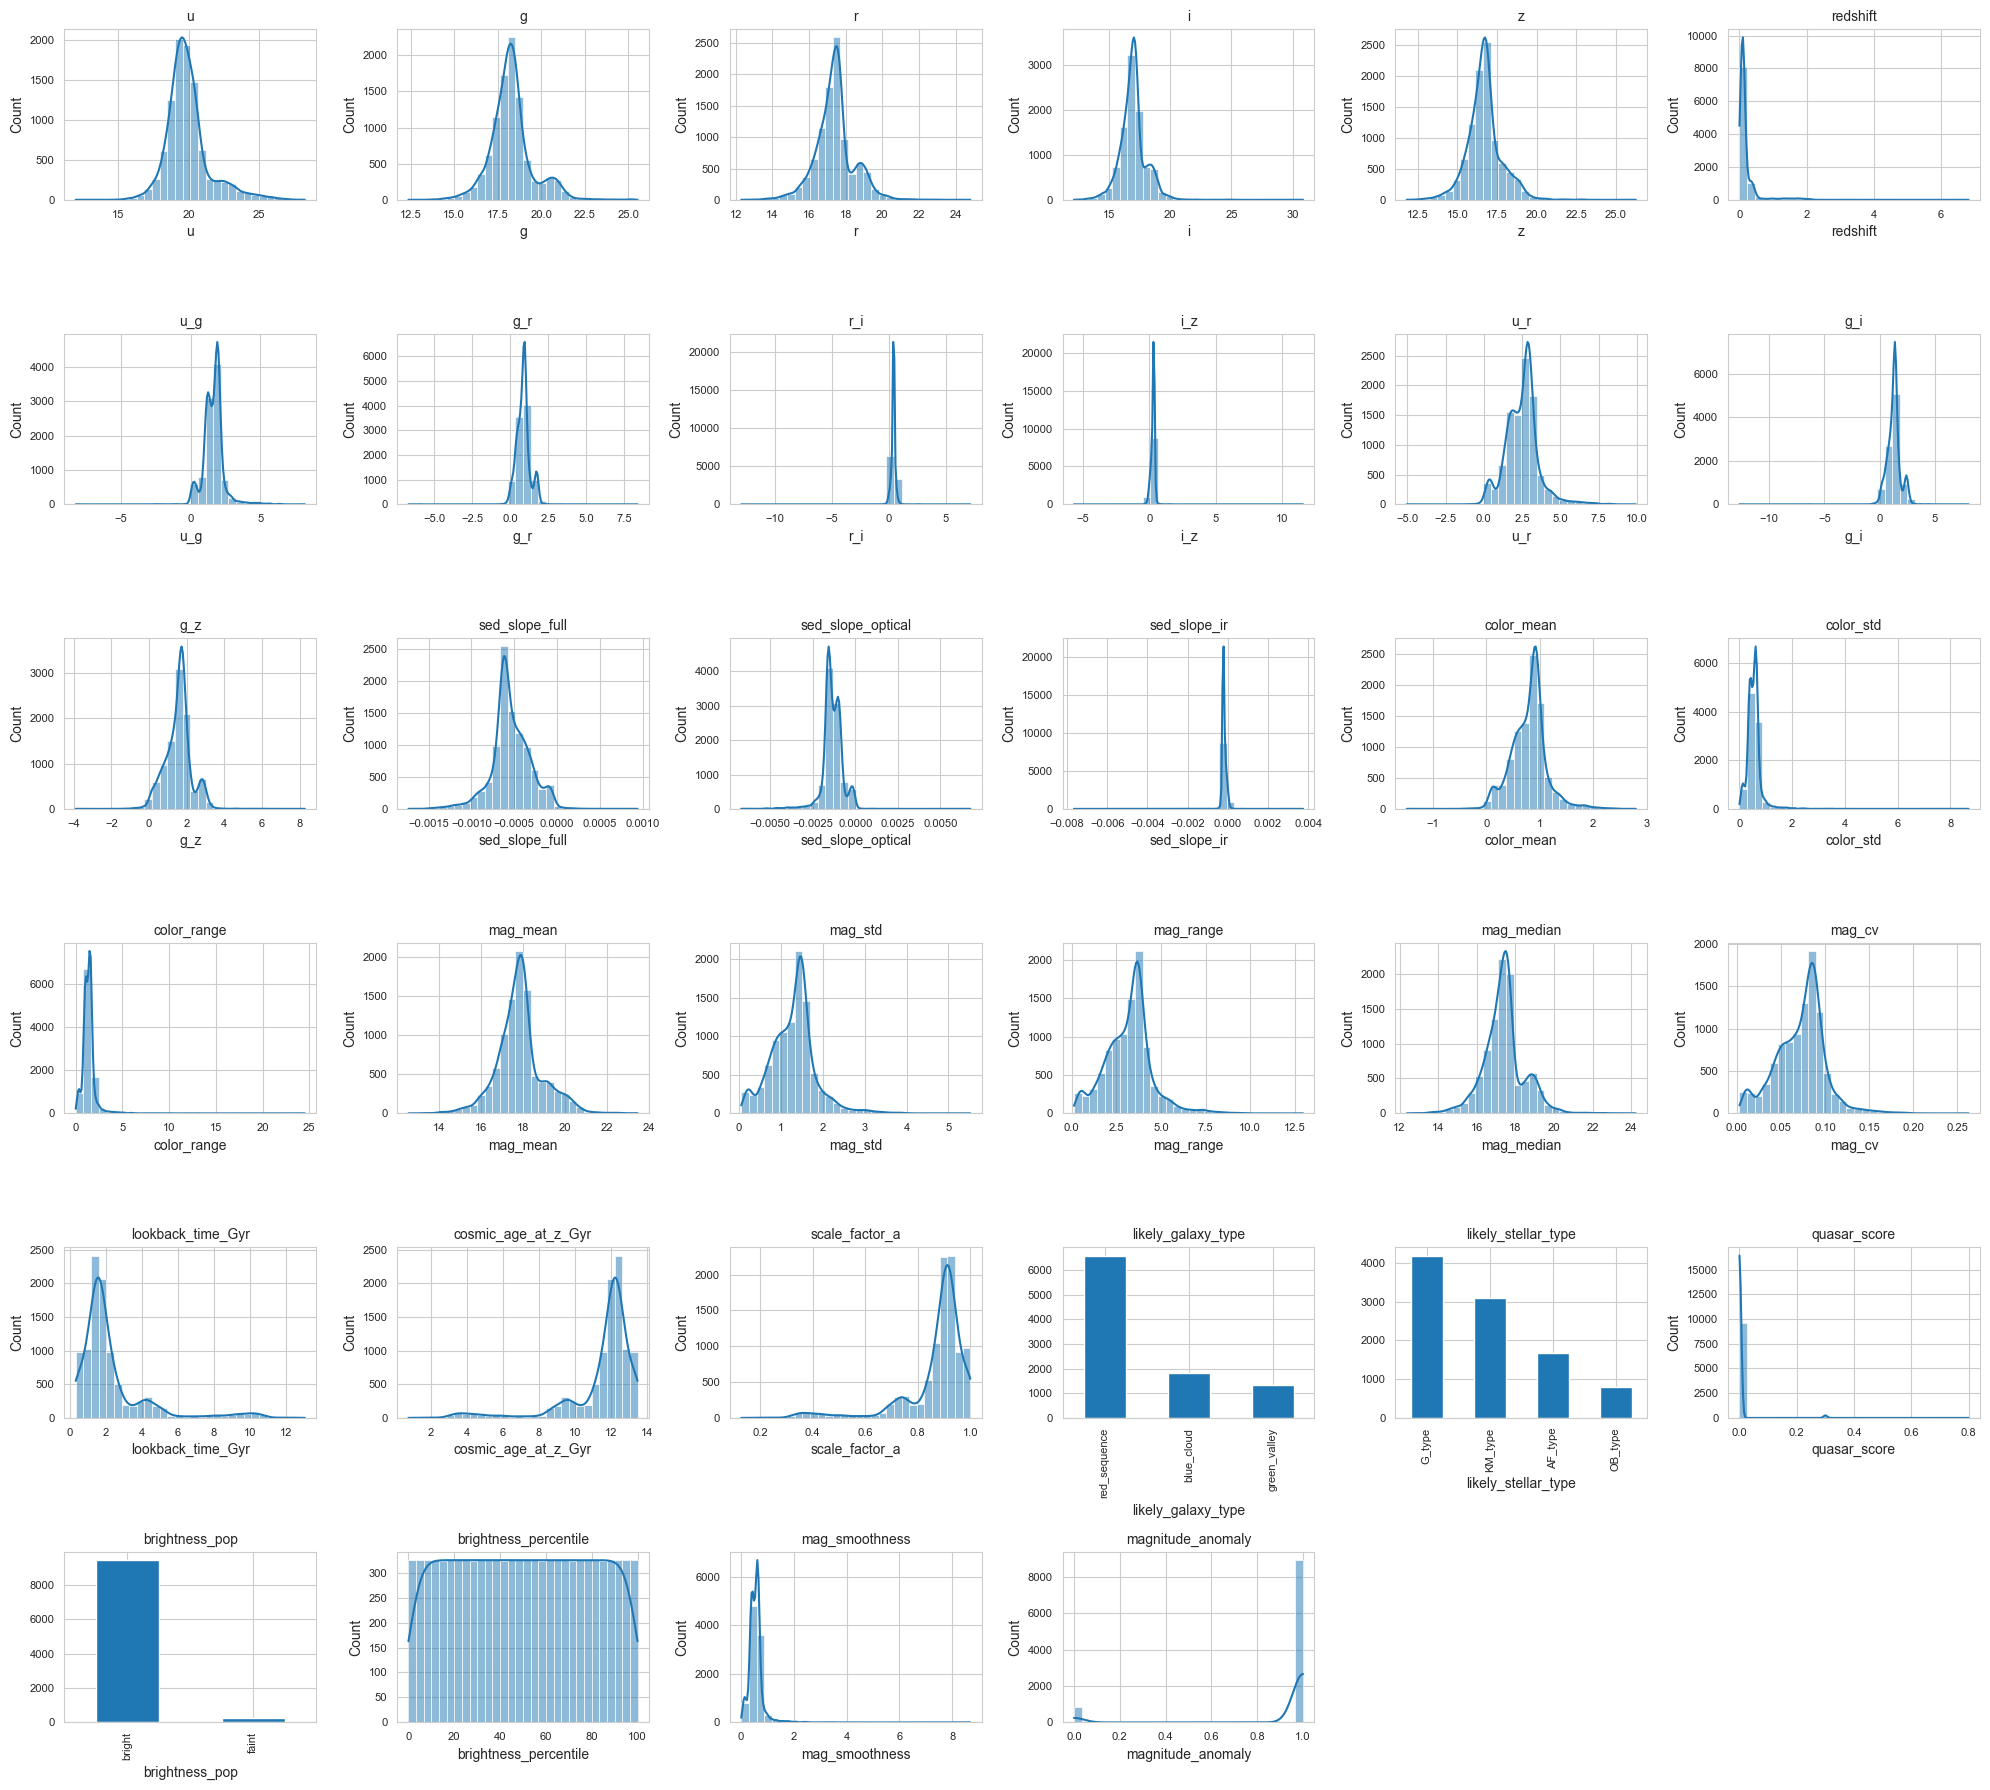

In [135]:
# Histograms for ALL features
n_features = len(X_features.columns)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(X_features.columns):
    if i < len(axes):
        # Handle categorical vs numerical
        if X_features[col].dtype == 'object' or col in ['likely_galaxy_type', 'likely_stellar_type', 'brightness_pop', 'z_regime']:
            # For categorical, use bar plot
            X_features[col].value_counts().plot(kind='bar', ax=axes[i])
        else:
            # For numerical, use histogram
            sns.histplot(X_features[col].dropna(), ax=axes[i], kde=True, bins=30)
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].tick_params(axis='both', which='major', labelsize=8)

# Hide empty subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

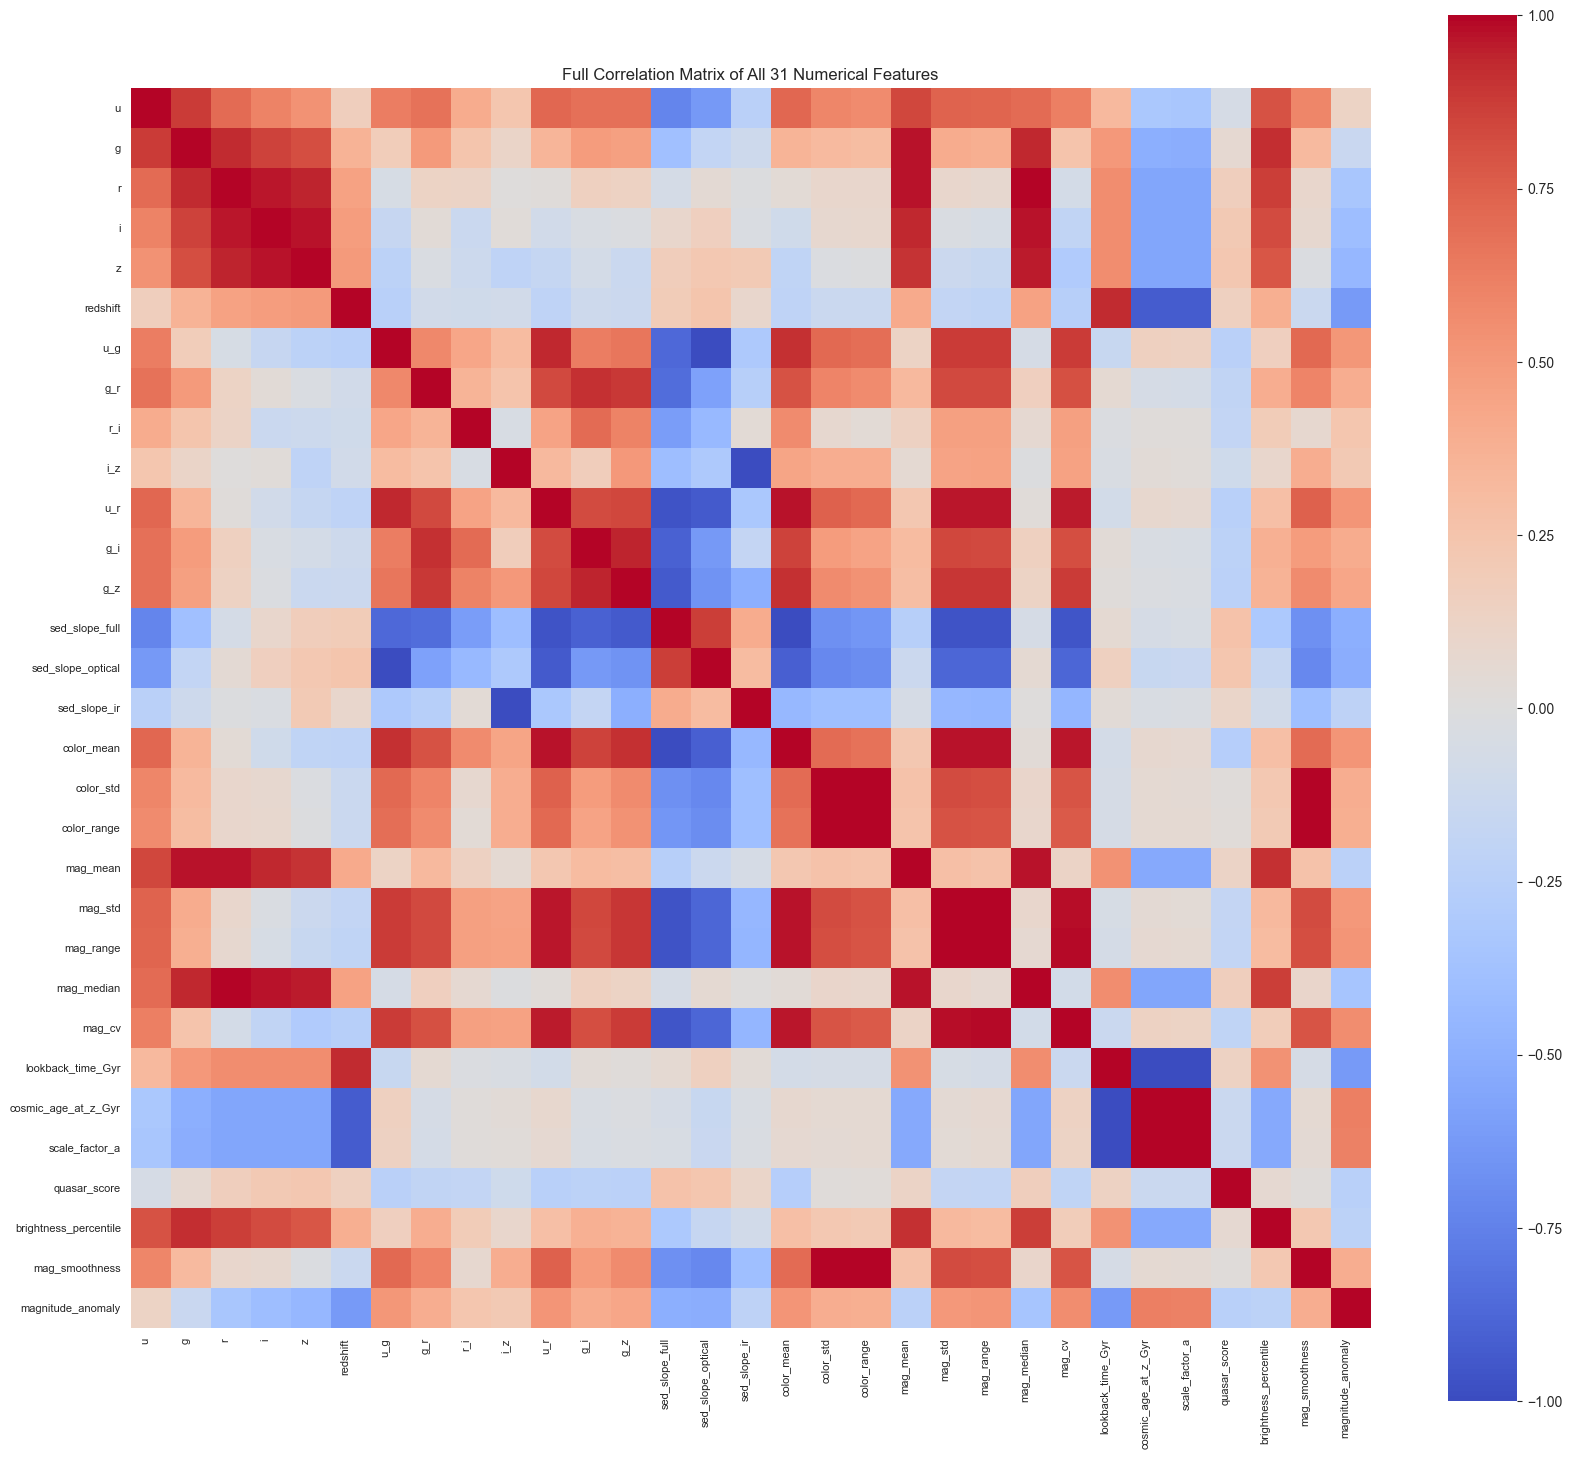

In [136]:
# Full correlation matrix for ALL numerical features
numerical_features = X_features.select_dtypes(include=[np.number]).columns
full_corr = X_features[numerical_features].corr()
plt.figure(figsize=(20, 18))
sns.heatmap(full_corr, annot=False, cmap='coolwarm', center=0, square=True)
plt.title(f'Full Correlation Matrix of All {len(numerical_features)} Numerical Features')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.show()

In [137]:
# Extract high correlations and group by strength bands (85%, 90%, 95%)
def extract_high_correlations(corr_matrix, min_corr=0.85):
    """Extract correlation pairs above threshold, excluding self-correlations"""
    corr_pairs = []

    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):  # Only upper triangle to avoid duplicates
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) >= min_corr:
                corr_pairs.append({
                    'Feature 1': corr_matrix.columns[i],
                    'Feature 2': corr_matrix.columns[j],
                    'Correlation': corr_value,
                    'Abs_Correlation': abs(corr_value)
                })

    return pd.DataFrame(corr_pairs).sort_values('Abs_Correlation', ascending=False)

# Extract high correlations
high_corr_df = extract_high_correlations(full_corr, min_corr=0.90)

# Group by correlation strength bands
print("="*80)
print("HIGH CORRELATIONS GROUPED BY STRENGTH BANDS")
print("="*80)

bands = [
    (0.95, 1.00, '95% and above'),
    (0.90, 0.95, '90% - 95%')
]

for lower, upper, label in bands:
    band_data = high_corr_df[(high_corr_df['Abs_Correlation'] >= lower) & (high_corr_df['Abs_Correlation'] < upper)]
    print(f"\n{label} Correlations ({len(band_data)} pairs):")
    print("-" * 80)
    if len(band_data) > 0:
        for idx, row in band_data.iterrows():
            print(f"  {row['Feature 1']:25s} ↔ {row['Feature 2']:25s} : {row['Correlation']:7.4f}")
    else:
        print("  No correlations found in this band")

# Overall summary
print(f"\n{'='*80}")
print(f"SUMMARY: Total high correlations (≥90%): {len(high_corr_df)}")
print(f"{'='*80}")
print("\nDetailed table:")
print(high_corr_df.to_string(index=False))


HIGH CORRELATIONS GROUPED BY STRENGTH BANDS

95% and above Correlations (28 pairs):
--------------------------------------------------------------------------------
  lookback_time_Gyr         ↔ cosmic_age_at_z_Gyr       : -1.0000
  lookback_time_Gyr         ↔ scale_factor_a            : -0.9998
  cosmic_age_at_z_Gyr       ↔ scale_factor_a            :  0.9998
  mag_std                   ↔ mag_range                 :  0.9988
  color_range               ↔ mag_smoothness            :  0.9969
  color_std                 ↔ color_range               :  0.9969
  sed_slope_full            ↔ color_mean                : -0.9943
  r                         ↔ mag_median                :  0.9926
  mag_range                 ↔ mag_cv                    :  0.9869
  mag_std                   ↔ mag_cv                    :  0.9840
  mag_mean                  ↔ mag_median                :  0.9764
  g                         ↔ mag_mean                  :  0.9759
  i                         ↔ mag_median   

Dropping 24 features with ≥90% correlation...
Features being dropped: ['lookback_time_Gyr', 'cosmic_age_at_z_Gyr', 'scale_factor_a', 'log_luminosity_solar', 'mag_smoothness', 'color_range', 'sed_slope_ir', 'sed_slope_optical', 'mag_range', 'mag_cv', 'mag_median', 'color_mean', 'd_luminosity_Mpc', 'd_comoving_Mpc', 'd_proper_Mpc', 'distance_modulus', 'brightness_percentile', 'g_i', 'u_r', 'g_z', 'mag_mean', 'magnitude_anomaly', 'mag_std', 'z_regime']

REMAINING FEATURES: 16 (from 34)

Remaining numerical features:
   1. u
   2. g
   3. r
   4. i
   5. z
   6. redshift
   7. u_g
   8. g_r
   9. r_i
  10. i_z
  11. sed_slope_full
  12. color_std
  13. quasar_score

Remaining categorical features:
   1. likely_galaxy_type
   2. likely_stellar_type
   3. brightness_pop

CORRELATION MATRIX OF REMAINING FEATURES


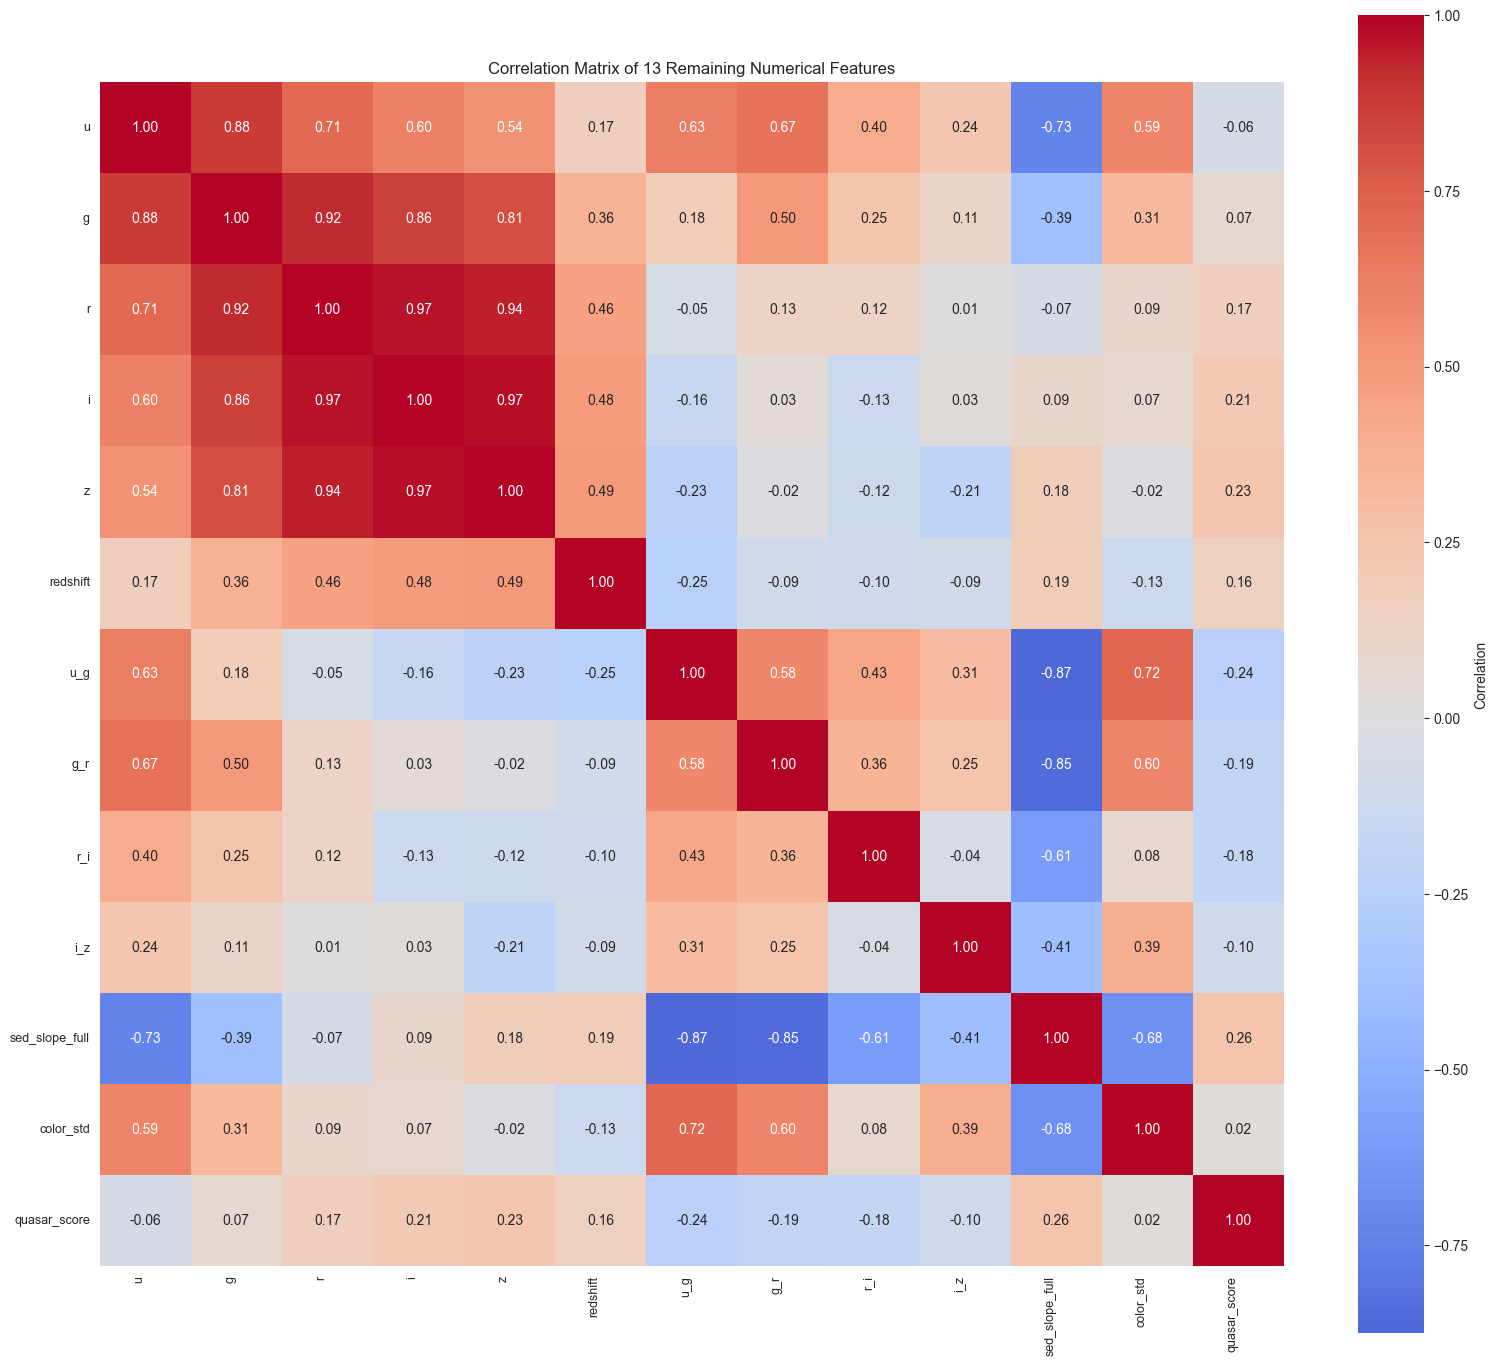

In [138]:
# Drop features
features_to_drop = [
    # High correlations >90%
    'lookback_time_Gyr',
    'cosmic_age_at_z_Gyr',
    'scale_factor_a',
    'log_luminosity_solar',
    'mag_smoothness',
    'color_range',
    'sed_slope_ir',
    'sed_slope_optical',
    'mag_range',
    'mag_cv',
    'mag_median',
    'color_mean',
    'd_luminosity_Mpc',
    'd_comoving_Mpc',
    'd_proper_Mpc',
    'distance_modulus',
    'brightness_percentile',
    'g_i',
    'u_r',
    'g_z',
    'mag_mean',  # r=0.98 with g
    'magnitude_anomaly',  # just a flag
    'mag_std', # r=0.966 with sed_slope_full
    'z_regime'  # (categorical; redshift is better)
]

print(f"Dropping {len(features_to_drop)} features with ≥90% correlation...")
print(f"Features being dropped: {features_to_drop}")
print()

# Drop the features from X_features
X_features_filtered = X_features.drop(columns=features_to_drop, errors='ignore')

print("="*80)
print(f"REMAINING FEATURES: {len(X_features_filtered.columns)} (from {len(X_features.columns)})")
print("="*80)
print("\nRemaining numerical features:")
remaining_numerical = X_features_filtered.select_dtypes(include=[np.number]).columns.tolist()
for i, feat in enumerate(remaining_numerical, 1):
    print(f"  {i:2d}. {feat}")

print("\nRemaining categorical features:")
remaining_categorical = X_features_filtered.select_dtypes(exclude=[np.number]).columns.tolist()
for i, feat in enumerate(remaining_categorical, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n{'='*80}")
print("CORRELATION MATRIX OF REMAINING FEATURES")
print(f"{'='*80}")

# Compute new correlation matrix for remaining numerical features
remaining_corr = X_features_filtered[remaining_numerical].corr()

# Display correlation matrix
plt.figure(figsize=(16, 14))
sns.heatmap(remaining_corr, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title(f'Correlation Matrix of {len(remaining_numerical)} Remaining Numerical Features')
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [139]:
print(f"X_features_filtered shape: {X_features_filtered.shape}")
print(f"X_features_filtered columns: {list(X_features_filtered.columns)}")

X_features_filtered shape: (9744, 16)
X_features_filtered columns: ['u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z', 'sed_slope_full', 'color_std', 'likely_galaxy_type', 'likely_stellar_type', 'quasar_score', 'brightness_pop']


In [140]:
# Basic statistics for ALL engineered features
print("Summary statistics for all 18 features:")
X_features_filtered.describe().T  # Transpose for better readability

Summary statistics for all 18 features:


,count,mean,std,min,25%,50%,75%,max
u,9744.0,19.907014,1.536770,11.960910,19.034585,19.680960,20.438260,28.238530
g,9744.0,18.273652,1.218813,12.374760,17.612568,18.192615,18.718367,25.532540
r,9744.0,17.399159,1.063988,12.297430,16.834655,17.389270,17.789500,24.801930
i,9744.0,16.991397,1.065531,12.184350,16.429282,16.976215,17.386222,30.831510
z,9744.0,16.709745,1.088634,11.806450,16.120378,16.677580,17.152540,26.259070
redshift,9744.0,0.193853,0.334260,0.000000,0.071194,0.103591,0.162942,6.827977
u_g,9744.0,1.633362,0.738189,-8.235660,1.226665,1.681500,1.971430,8.175870
g_r,9744.0,0.874493,0.475746,-6.683520,0.595660,0.881840,1.053355,8.396770
r_i,9744.0,0.407761,0.272133,-12.963090,0.351247,0.424610,0.477973,7.161740
i_z,9744.0,0.281652,0.252033,-5.649330,0.214387,0.317025,0.364583,11.546050


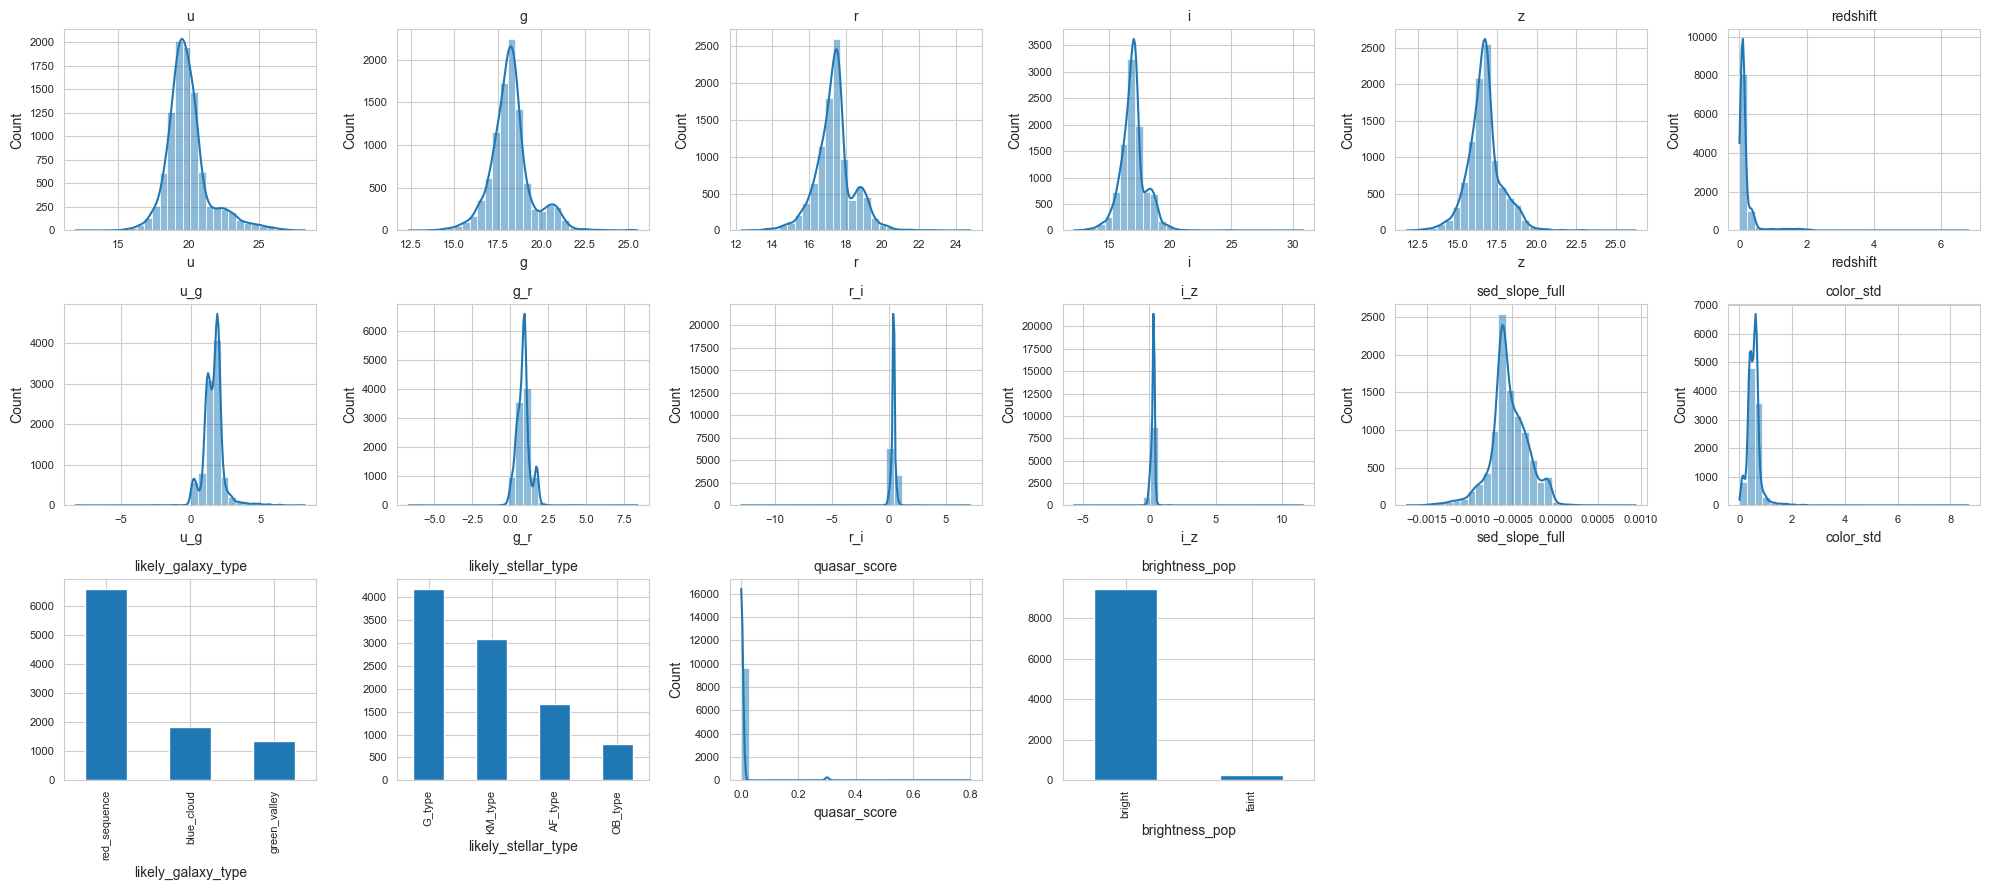

In [141]:
# Histograms for ALL 18 features
n_features = len(X_features_filtered.columns)
n_cols = 6
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3*n_rows))
axes = axes.flatten()

for i, col in enumerate(X_features_filtered.columns):
    if i < len(axes):
        # Handle categorical vs numerical
        if X_features[col].dtype == 'object' or col in ['likely_galaxy_type', 'likely_stellar_type', 'brightness_pop', 'z_regime']:
            # For categorical, use bar plot
            X_features[col].value_counts().plot(kind='bar', ax=axes[i])
        else:
            # For numerical, use histogram
            sns.histplot(X_features_filtered[col].dropna(), ax=axes[i], kde=True, bins=30)
        axes[i].set_title(f'{col}', fontsize=10)
        axes[i].tick_params(axis='both', which='major', labelsize=8)

# Hide empty subplots
for i in range(n_features, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Scaling and Preprocessing

 ~14% outliers in redshift and ~8-10% in magnitude bands.

In [142]:
FINAL_FEATURES = [
    'u', 'g', 'r', 'i', 'z', 'redshift',
    'u_g', 'g_r', 'r_i', 'i_z',
    'color_std', 'sed_slope_full',
    'quasar_score', 'likely_galaxy_type', 'likely_stellar_type',
    'brightness_pop'
]

X_scaled = X_features_filtered[FINAL_FEATURES].copy()

# Identify numeric features
numeric_features = [f for f in FINAL_FEATURES
                   if X_scaled[f].dtype in ['float64', 'int64']]
categorical_features = [f for f in FINAL_FEATURES if f not in numeric_features]

# Apply QuantileTransformer to ALL numeric features
quantile_scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_scaled[numeric_features] = quantile_scaler.fit_transform(X_features_filtered[numeric_features])

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"\nStatistics:")
print(X_scaled.describe())


Scaled data shape: (9744, 16)

Statistics:
                 u            g            r            i            z  \
count  9744.000000  9744.000000  9744.000000  9744.000000  9744.000000   
mean      0.000123     0.000156     0.000140    -0.000036     0.000015   
std       1.000863     1.001382     1.001900     1.000747     1.000898   
min      -5.199338    -5.199338    -5.199338    -5.199338    -5.199338   
25%      -0.674608    -0.674322    -0.674186    -0.674561    -0.675429   
50%       0.000500     0.000132     0.000348     0.000213     0.000391   
75%       0.674198     0.674132     0.674931     0.674464     0.674195   
max       5.199338     5.199338     5.199338     5.199338     5.199338   

          redshift          u_g          g_r          r_i          i_z  \
count  9744.000000  9744.000000  9744.000000  9744.000000  9744.000000   
mean     -0.002181     0.000103    -0.000013     0.000042     0.000009   
std       1.009596     1.001077     1.001088     1.000429     1.000

# Save Scaled Data

Save the scaled features along with target labels for downstream clustering and analysis.

In [144]:
# Create dataframe with scaled features and labels (using filtered labels)
df_scaled = X_scaled.copy()
df_scaled['class'] = y.reset_index(drop=True)  # Reset index to match X_scaled

# Save to CSV
output_path = 'astral_scaled.csv'
df_scaled.to_csv(output_path, index=False)
print(f"✓ Scaled data saved to: {output_path}")
print(f"  Shape: {df_scaled.shape}")
print(f"  Columns: {df_scaled.shape[1]}")

# Display summary
print(f"\nData saved with {df_scaled.shape[0]} samples and {df_scaled.shape[1]} features (including class)")
print(f"Class distribution:\n{df_scaled['class'].value_counts()}")

✓ Scaled data saved to: astral_scaled.csv
  Shape: (9744, 17)
  Columns: 17

Data saved with 9744 samples and 17 features (including class)
Class distribution:
class
GALAXY    8224
QSO        670
STAR       602
Name: count, dtype: int64
